<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment10/DNN_Assignment_10_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Library Import

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# Autoencoder

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),  # for image output
            nn.Unflatten(1, (1, 28, 28))
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


# Load MNIST Dataset

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:11<00:00, 890kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 241kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.41MB/s]


# Model Train

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
epochs = 20
model.train()
for epoch in range(epochs):
    total_loss = 0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        recon, mu, logvar = model(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(mnist)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 50.8254
Epoch [2/20], Loss: 37.9412
Epoch [3/20], Loss: 34.1051
Epoch [4/20], Loss: 32.4485
Epoch [5/20], Loss: 31.5476
Epoch [6/20], Loss: 30.8599
Epoch [7/20], Loss: 30.3911
Epoch [8/20], Loss: 30.0472
Epoch [9/20], Loss: 29.7721
Epoch [10/20], Loss: 29.5336
Epoch [11/20], Loss: 29.3281
Epoch [12/20], Loss: 29.1901
Epoch [13/20], Loss: 29.0408
Epoch [14/20], Loss: 28.8919
Epoch [15/20], Loss: 28.7895
Epoch [16/20], Loss: 28.6827
Epoch [17/20], Loss: 28.5793
Epoch [18/20], Loss: 28.5195
Epoch [19/20], Loss: 28.4268
Epoch [20/20], Loss: 28.3763


# Evaluation: calculate reconstruction MSE on 1000 samples

In [6]:
model.eval()
test_loader = DataLoader(mnist, batch_size=1000, shuffle=False)
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    recon, _, _ = model(imgs)
    mse = F.mse_loss(recon, imgs)
    print(f"\nReconstruction MSE on 1000 test images: {mse.item():.6f}")



Reconstruction MSE on 1000 test images: 0.020889


# Visualize 4 original and 4 reconstructed images


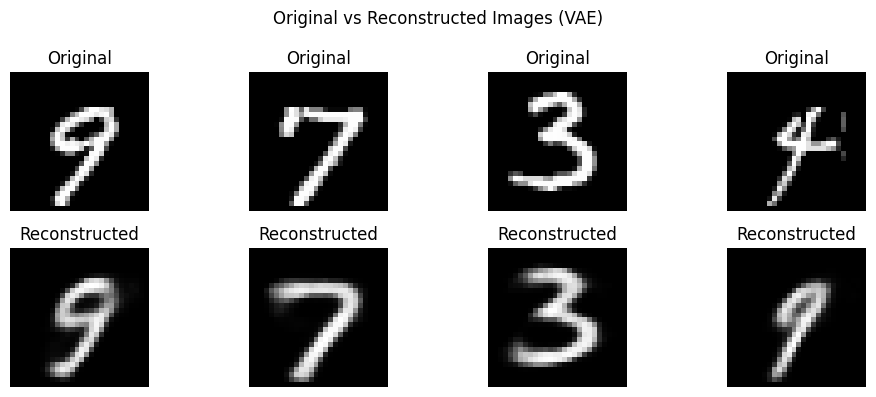

In [17]:
imgs, _ = next(iter(test_loader))
imgs = imgs.to(device)
with torch.no_grad():
    recon, _, _ = model(imgs)
rand_indices = random.sample(range(len(imgs)), 4)
fig, axes = plt.subplots(2, 4, figsize=(10, 4))
for i, idx in enumerate(rand_indices):
    axes[0, i].imshow(imgs[idx].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(recon[idx].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.suptitle("Original vs Reconstructed Images (VAE)")
plt.tight_layout()
plt.show()


# Generate Noise Vectors (mean=5, variance=1)

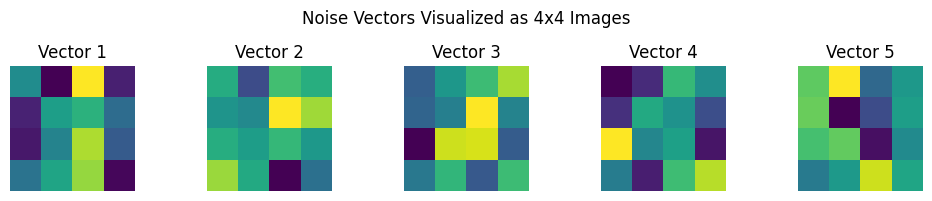

In [8]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16))
plt.figure(figsize=(10, 2))
for i in range(5):
    vector_image = noise_vectors[i].reshape(4, 4).cpu().numpy()
    plt.subplot(1, 5, i + 1)
    plt.imshow(vector_image)
    plt.title(f"Vector {i+1}")
    plt.axis('off')

plt.suptitle("Noise Vectors Visualized as 4x4 Images")
plt.tight_layout()
plt.show()

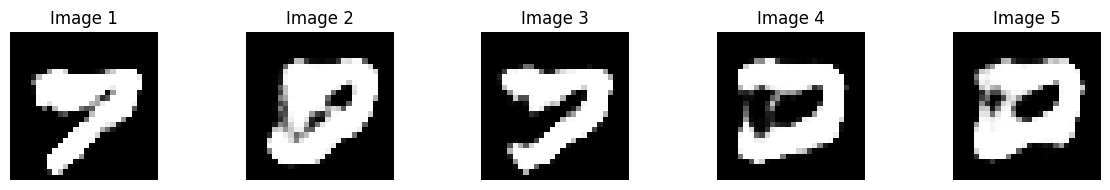

In [26]:
noise_vectors = torch.normal(mean=5.0, std=2.0, size=(5, 16)).to(device)
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()
plt.figure(figsize=(12, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Plot the Results

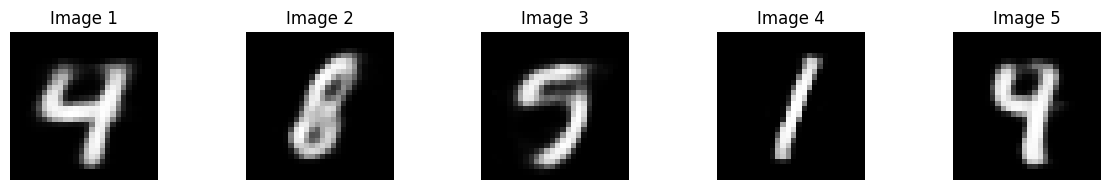

In [29]:
# Generate realistic latent vectors (mean=0, std=1)
noise_vectors = torch.randn(5, 16).to(device)  # try this instead of mean=5

# Pass through decoder
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()

# Plot
plt.figure(figsize=(12, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')

# plt.suptitle("Generated Images from Latent Space (mean=0, std=1)")
plt.tight_layout()
plt.show()
